In [3]:
import requests
import pandas as pd
import re
import time
import feedparser
from bs4 import BeautifulSoup
from urllib.parse import quote

# ==========================================
# CONFIG
# ==========================================

TARGET_ROWS = 500
WORDS_PER_CHUNK = 120

HEADERS = {
    "User-Agent": "Mozilla/5.0"
}

RSS_FEEDS = {
    "NDTV": "https://feeds.feedburner.com/ndtvnews-top-stories",
    "IndiaToday": "https://www.indiatoday.in/rss/home",
    "TheHindu": "https://www.thehindu.com/news/national/feeder/default.rss",
    "HindustanTimes": "https://www.hindustantimes.com/feeds/rss/india-news/rssfeed.xml",
    "IndianExpress": "https://indianexpress.com/section/india/feed/",
    "TimesOfIndia": "https://timesofindia.indiatimes.com/rssfeeds/-2128936835.cms",
    "News18": "https://www.news18.com/commonfeeds/v1/eng/rss/india.xml"
}

# ==========================================
# PERSON KEYWORDS
# ==========================================

PERSON_KEYWORDS = {
    "Mamata Banerjee": [
        "mamata banerjee",
        "mamata didi",
        "didi",
        "tmc chief",
        "trinamul congress",
        "tmc supremo",
        "west bengal chief minister",
        "bengal cm",
        "bhabanipur",
        "kalighat",
        "diamond harbour",
        "tmc rally",
        "tmc campaign",
        "tmc workers",
        "bjp vs tmc",
        "assembly election",
        "west bengal election",
        "campaign speech",
        "rally speech",
        "vote appeal",
        "women voters",
        "minority vote",
        "muslim vote",
        "delimitation",
        "roadshow",
        "public meeting",
        "poll violence",
        "booth capture",
        "outsider",
        "double engine government",
        "jai shri ram slogan",
        "sandeshkhali",
        "nandigram"
    ],

    "Suvendu Adhikari": [
        "suvendu adhikari",
        "suvendu",
        "leader of opposition",
        "bjp leader",
        "bengal bjp",
        "nandigram mla",
        "bjp rally",
        "bjp campaign",
        "west bengal election",
        "assembly election",
        "campaign speech",
        "rally speech",
        "mamata didi",
        "tmc corruption",
        "cut money",
        "minority appeasement",
        "cow slaughter",
        "uniform civil code",
        "ucc",
        "illegal infiltration",
        "bangladeshi infiltration",
        "border sealing",
        "sandeshkhali",
        "law and order",
        "poll violence",
        "booth capture",
        "roadshow",
        "public meeting",
        "hindu vote",
        "muslim vote"
    ]
}

PERSON_ARTICLE_FILTERS = {
    "Mamata Banerjee": [
        "mamata banerjee said",
        "mamata banerjee alleged",
        "mamata banerjee claimed",
        "mamata banerjee accused",
        "mamata banerjee warned",
        "mamata banerjee slammed",
        "mamata banerjee hit out",
        "mamata banerjee addressed",
        "mamata banerjee speech",
        "mamata banerjee rally",
        "mamata didi said",
        "didi said",
        "tmc chief said",
        "chief minister mamata banerjee",
        "mamata banerjee roadshow",
        "mamata banerjee on bjp",
        "mamata banerjee on election",
        "mamata banerjee on violence"
    ],

    "Suvendu Adhikari": [
        "suvendu adhikari said",
        "suvendu adhikari alleged",
        "suvendu adhikari claimed",
        "suvendu adhikari accused",
        "suvendu adhikari warned",
        "suvendu adhikari slammed",
        "suvendu adhikari hit out",
        "suvendu adhikari addressed",
        "suvendu adhikari speech",
        "suvendu adhikari rally",
        "leader of opposition said",
        "bjp leader said",
        "suvendu said",
        "suvendu adhikari roadshow",
        "suvendu adhikari on tmc",
        "suvendu adhikari on corruption",
        "suvendu adhikari on infiltration",
        "suvendu adhikari on ucc"
    ]
}

# ==========================================
# CLEAN TEXT
# ==========================================

def clean_text(text):
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^\w\s.,!?\"'%-]", " ", text)
    return text.strip()

# ==========================================
# EXTRACT ARTICLE TEXT
# ==========================================

def extract_article_text(url):
    try:
        response = requests.get(url, headers=HEADERS, timeout=20)

        if response.status_code != 200:
            return ""

        soup = BeautifulSoup(response.text, "html.parser")

        for tag in soup(["script", "style", "nav", "footer", "header", "aside"]):
            tag.decompose()

        paragraphs = soup.find_all("p")

        text = " ".join([
            p.get_text(" ", strip=True)
            for p in paragraphs
            if len(p.get_text(strip=True)) > 20
        ])

        return clean_text(text)

    except Exception as e:
        print(f"Error extracting article: {url}")
        print(e)
        return ""

# ==========================================
# SPLIT TEXT
# ==========================================

def generate_chunks(text, words_per_chunk=120):
    words = text.split()
    chunks = []

    for i in range(0, len(words), words_per_chunk):
        chunk = words[i:i + words_per_chunk]

        if len(chunk) >= 80:
            chunks.append(" ".join(chunk))

    return chunks

# ==========================================
# EXTRACT QUOTES
# ==========================================

def extract_quotes(text, person):
    quotes = []

    quote_patterns = [
        r'"([^"]{30,700})"',
        r"'([^']{30,700})'",
        r'“([^”]{30,700})”',
        r'‘([^’]{30,700})’'
    ]

    person_filters = PERSON_ARTICLE_FILTERS[person]

    speech_words = [
        "said", "stated", "claimed", "accused", "warned",
        "slammed", "alleged", "added", "announced",
        "declared", "told", "hit out", "attacked", "addressed"
    ]

    relevant_topics = [
        "bjp", "tmc", "didi", "election", "poll", "vote",
        "minority", "women", "violence", "ucc",
        "cow slaughter", "sandeshkhali", "infiltration",
        "corruption", "delimitation", "rally",
        "campaign", "roadshow", "hindus", "muslims"
    ]

    for pattern in quote_patterns:
        matches = re.finditer(pattern, text)

        for match in matches:
            quote_text = clean_text(match.group(1))

            if len(quote_text.split()) < 8:
                continue

            start_pos = max(0, match.start() - 300)
            end_pos = min(len(text), match.end() + 300)

            context = text[start_pos:end_pos].lower()

            has_person = any(p in context for p in person_filters)
            has_speech = any(w in context for w in speech_words)
            has_topic = any(t in quote_text.lower() for t in relevant_topics)

            if has_person and (has_speech or has_topic):
                quotes.append(quote_text)

    return list(set(quotes))

# ==========================================
# SEARCH GDELT
# ==========================================

def search_gdelt(person, max_records=800):
    print(f"\nSearching GDELT for {person}")

    keywords = PERSON_KEYWORDS[person]

    query_parts = [
        f'"{person}"',
        '"West Bengal"',
        '"Bengal election"',
        '"assembly election"',
        '"campaign speech"',
        '"rally"',
        '"roadshow"',
        '"public meeting"',
        '"vote appeal"',
        '"BJP"',
        '"TMC"',
        '"poll violence"',
        '"women voters"',
        '"minority vote"',
        '"sandeshkhali"',
        '"nandigram"',
        '"bhabanipur"',
        '"cut money"',
        '"illegal infiltration"',
        '"uniform civil code"'
    ]

    for keyword in keywords:
        query_parts.append(f'"{keyword}"')

    query = " OR ".join(query_parts)

    url = (
        "https://api.gdeltproject.org/api/v2/doc/doc"
        f"?query={quote(query)}"
        "&mode=ArtList"
        "&maxrecords=800"
        "&format=json"
        "&sort=DateDesc"
        "&timespan=6months"
    )

    articles = []

    try:
        response = requests.get(url, headers=HEADERS, timeout=40)

        if response.status_code != 200:
            return []

        if "application/json" not in response.headers.get("Content-Type", ""):
            return []

        data = response.json()

        for article in data.get("articles", []):
            title = article.get("title", "")
            source = article.get("sourceCommonName", "")
            article_url = article.get("url", "")
            published = article.get("seendate", "")

            combined = f"{title} {source}".lower()

            if any(keyword.lower() in combined for keyword in keywords):
                articles.append({
                    "title": title,
                    "url": article_url,
                    "source": source,
                    "published": published
                })

    except Exception as e:
        print("GDELT Error:", e)

    return articles[:max_records]
# ==========================================
# SEARCH RSS
# ==========================================

def search_rss(person):
    print(f"\nSearching RSS feeds for {person}")

    keywords = PERSON_KEYWORDS[person]
    articles = []

    for source_name, rss_url in RSS_FEEDS.items():
        try:
            feed = feedparser.parse(rss_url)

            for entry in feed.entries:
                title = entry.get("title", "")
                summary = entry.get("summary", "")
                link = entry.get("link", "")
                published = entry.get("published", "")

                combined = f"{title} {summary}".lower()

                if any(keyword.lower() in combined for keyword in keywords):
                    articles.append({
                        "title": title,
                        "url": link,
                        "source": source_name,
                        "published": published
                    })

        except Exception as e:
            print(f"RSS error from {source_name}: {e}")

    return articles

# ==========================================
# BUILD DATASET
# ==========================================

def collect_person_dataset(person, target_rows=500):
    dataset = []

    gdelt_articles = search_gdelt(person)
    rss_articles = search_rss(person)

    all_articles = gdelt_articles + rss_articles

    seen_urls = set()

    important_context_phrases = [
        "bjp vs tmc",
        "poll violence",
        "minority appeasement",
        "cut money",
        "cow slaughter",
        "uniform civil code",
        "illegal infiltration",
        "double engine government",
        "sandeshkhali",
        "roadshow",
        "public meeting",
        "campaign speech",
        "women voters",
        "minority vote",
        "hindu vote",
        "muslim vote",
        "nandigram",
        "bhabanipur"
    ]

    for article in all_articles:
        if len(dataset) >= target_rows:
            break

        url = article["url"]

        if not url or url in seen_urls:
            continue

        seen_urls.add(url)

        title = article.get("title", "").lower()

        title_filters = [
            "mamata banerjee",
            "mamata didi",
            "suvendu adhikari",
            "tmc",
            "bjp",
            "west bengal election",
            "campaign",
            "rally",
            "speech",
            "roadshow",
            "sandeshkhali",
            "nandigram",
            "bhabanipur"
        ]

        if not any(t in title for t in title_filters):
            continue

        print(f"Scraping: {url}")

        text = extract_article_text(url)

        if len(text.split()) < 100:
            continue

        lower_text = text.lower()

        reject_terms = [
            "stock market",
            "sports news",
            "international news",
            "parliament session",
            "budget session"
        ]

        if any(term in lower_text for term in reject_terms):
            continue

        quotes = extract_quotes(text, person)
        chunks = generate_chunks(text, WORDS_PER_CHUNK)

        for quote in quotes:
            dataset.append({
                "person": person,
                "type": "quote",
                "exact_text": quote,
                "source": article["source"],
                "published": article["published"],
                "url": url,
                "word_count": len(quote.split())
            })

            if len(dataset) >= target_rows:
                break

        for chunk in chunks:
            if len(dataset) >= target_rows:
                break

            lower_chunk = chunk.lower()

            has_person_focus = any(
                phrase in lower_chunk
                for phrase in PERSON_ARTICLE_FILTERS[person]
            )

            has_context = any(
                phrase in lower_chunk
                for phrase in important_context_phrases
            )

            if has_person_focus or has_context:
                dataset.append({
                    "person": person,
                    "type": "context",
                    "exact_text": chunk,
                    "source": article["source"],
                    "published": article["published"],
                    "url": url,
                    "word_count": len(chunk.split())
                })

        time.sleep(1)

    df = pd.DataFrame(dataset)

    df = df.drop_duplicates(subset=["exact_text"])
    df = df.head(target_rows)

    filename = f"{person.lower().replace(' ', '_')}_focused_dataset.csv"
    df.to_csv(filename, index=False, encoding="utf-8-sig")

    print(f"\nSaved {len(df)} rows into {filename}")

    return df

# ==========================================
# RUN
# ==========================================

mamata_df = collect_person_dataset(
    person="Mamata Banerjee",
    target_rows=1000
)

suvendu_df = collect_person_dataset(
    person="Suvendu Adhikari",
    target_rows=1000
)

print("\nMamata Sample:")
print(mamata_df.head())

print("\nSuvendu Sample:")
print(suvendu_df.head())


Searching GDELT for Mamata Banerjee

Searching RSS feeds for Mamata Banerjee
Scraping: https://www.indiatoday.in/elections/assembly/story/assembly-election-2026-live-updates-april-17-tamil-nadu-west-bengal-kerala-puducherry-bjp-congress-tmc-dmk-aiadmk-rallies-result-details-2897509-2026-04-17?utm_source=rss
Scraping: https://www.indiatoday.in/india/story/bjp-womens-reservation-bill-lok-sabha-special-session-opposition-backlash-delimitation-2897603-2026-04-17?utm_source=rss
Scraping: https://www.indiatoday.in/india/story/parliament-session-live-updates-womens-reservation-bill-lok-sabha-rajya-sabha-deputy-chairman-election-delimitation-congress-bjp-2897446-2026-04-17?utm_source=rss
Scraping: https://www.thehindu.com/videos/delimitation-row-bjp-vs-congress-over-revanth-reddy-hybrid-model/article70873410.ece
Scraping: https://www.thehindu.com/news/national/assembly-elections-2026-west-bengal-tamil-nadu-kerala-assam-puducherry-april-17-2026-highlights/article70872100.ece
Scraping: https://

In [4]:
!pip install matplotlib-venn

DEPRECATION: Python 2.7 will reach the end of its life on January 1st, 2020. Please upgrade your Python as Python 2.7 won't be maintained after that date. A future version of pip will drop support for Python 2.7. More details about Python 2 support in pip, can be found at https://pip.pypa.io/en/latest/development/release-process/#python-2-support
  Using cached https://files.pythonhosted.org/packages/e8/f7/47bddf95492f4d1370ed7164d2b16407805e8eeb38231361de65d387a562/matplotlib-venn-1.1.2.tar.gz
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
  ERROR: Command errored out with exit status 1:
   command: /Library/Frameworks/Python.framework/Versions/2.7/Resources/Python.app/Contents/MacOS/Python /Library/Frameworks/Python.framework/Versions/2.7/lib/python2.7/site-packages/pip/_vendor/pep517/_in_process.py get_requires_for_build_wheel /var/folders/vw/x71ctk413sdd79zvc97fm81w0000gn/T/tmppHWZNd
       cwd: /private/var/folders/vw/x71ctk413sdd79zvc97fm

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/koustavsarkar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/koustavsarkar/nltk_data...
[nltk_data]   Package punkt is already up-to-date!



========== MAMATA TOPICS ==========

Topic 1:
['acquisition', 'bridge', 'group', 'roads', 'land', 'trinamool', 'resistance', 'political', 'movement', 'nandigram']

Topic 2:
['state', 'muraleedharan', 'total', 'chief', 'number', 'polling', 'alleged', 'union', 'kabir', 'minister']

Topic 3:
['minister', 'kabir', 'trinamool', 'women', 'congress', 'alleged', 'union', 'quota', 'law', 'amendment']

Topic 4:
['deeper', 'sense', 'cast', 'arrive', 'agitation', 'remains', 'land', 'completed', 'development', 'place']

Topic 5:
['news', 'trinamool', 'congress', 'politics', 'nandigram', 'minister', 'shah', 'amit', 'home', 'bhabanipur']

Topic 6:
['sharma', 'shankar', 'ghosh', 'drug', 'chief', 'minister', 'constituency', 'siliguri', 'candidate', 'assembly']

Topic 7:
['support', 'friday', 'contest', 'continues', 'ground', 'state', 'nandigram', 'minister', 'chief', 'political']

Topic 8:
['dietary', 'earlier', 'protect', 'accused', 'tamil', 'nadu', 'assam', 'sarma', 'minister', 'chief']

Topic 9:
['

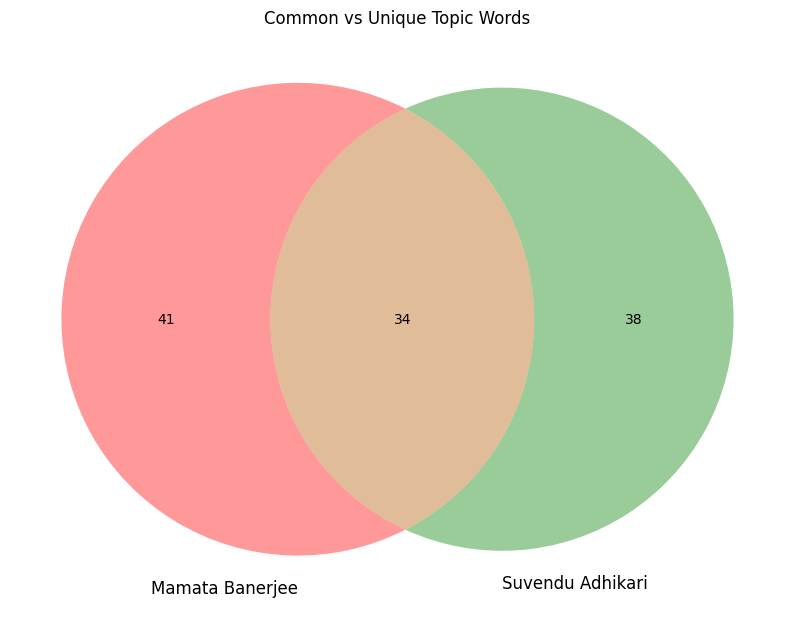

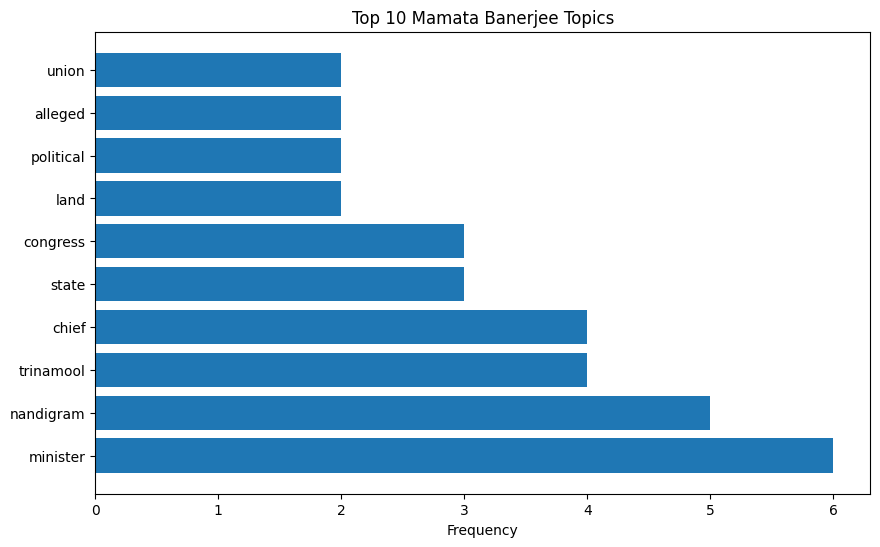

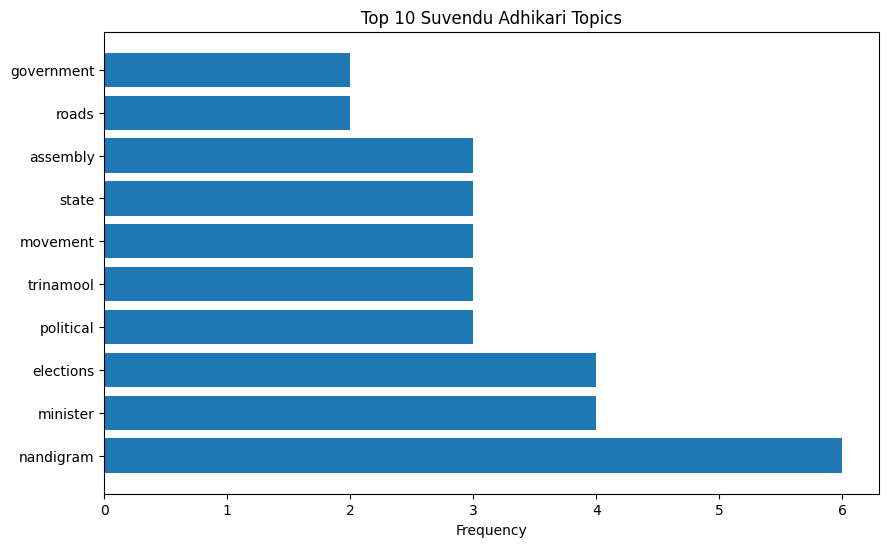

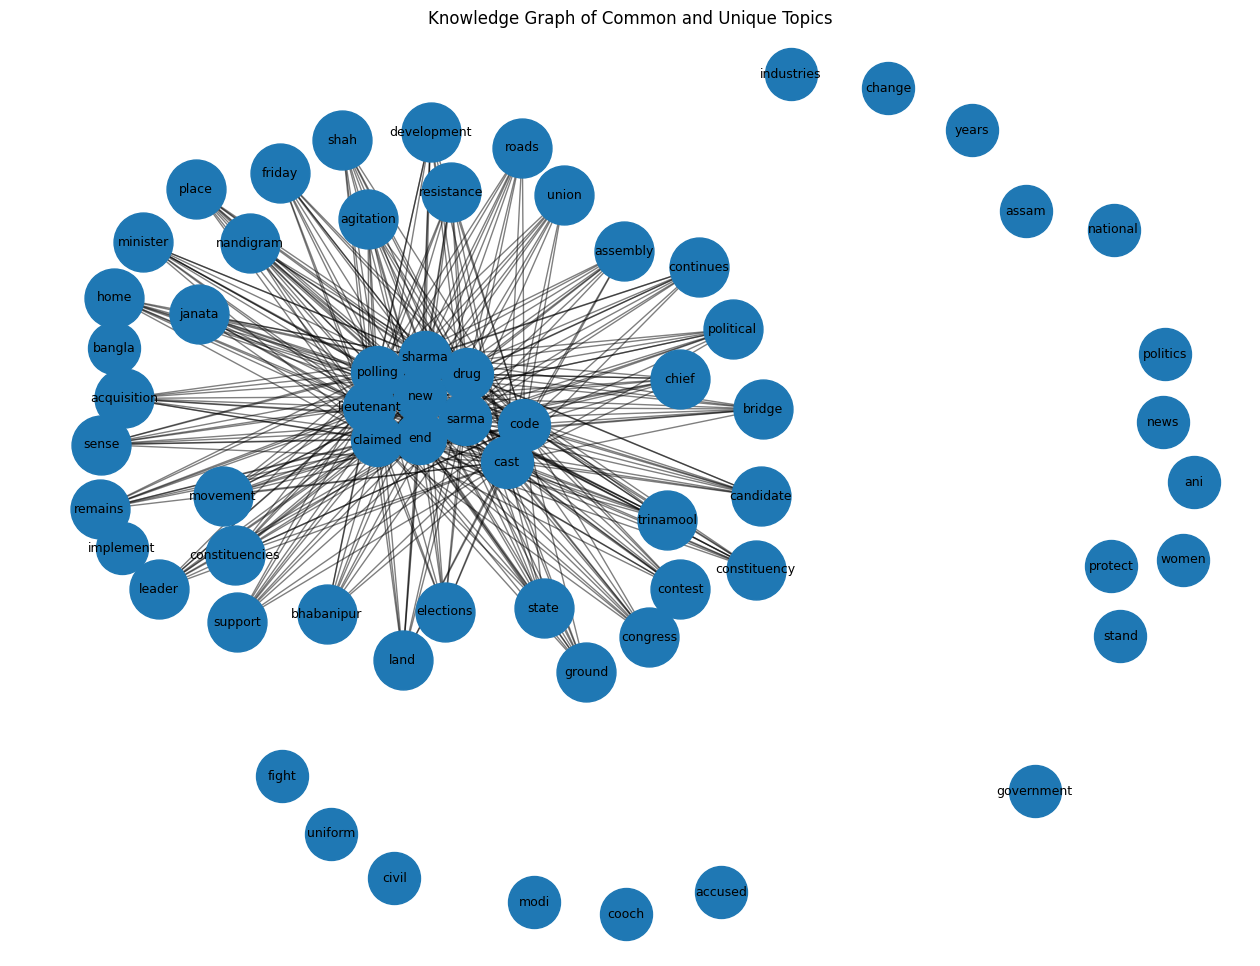

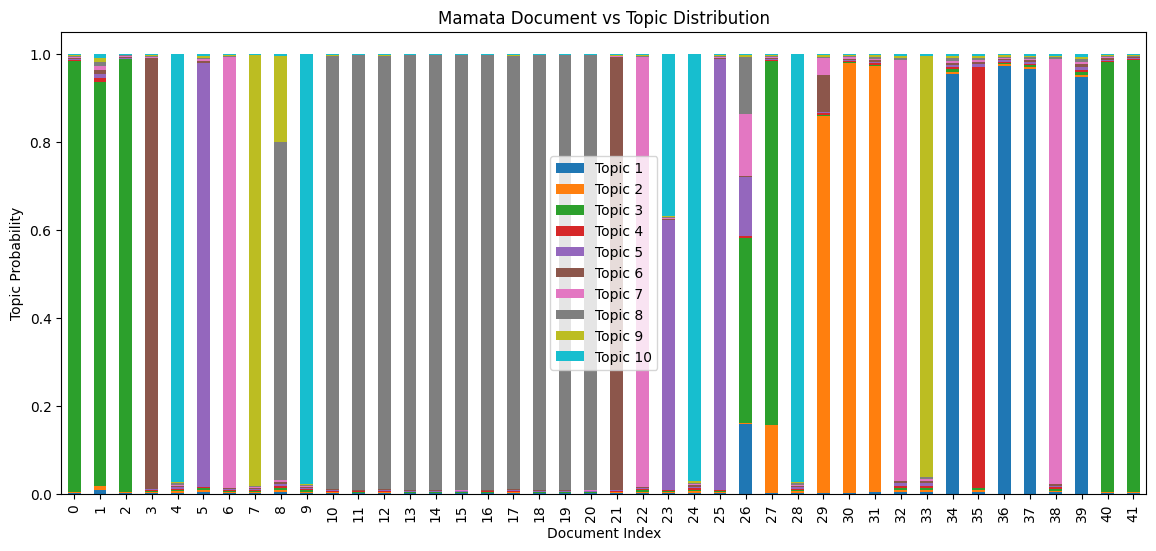

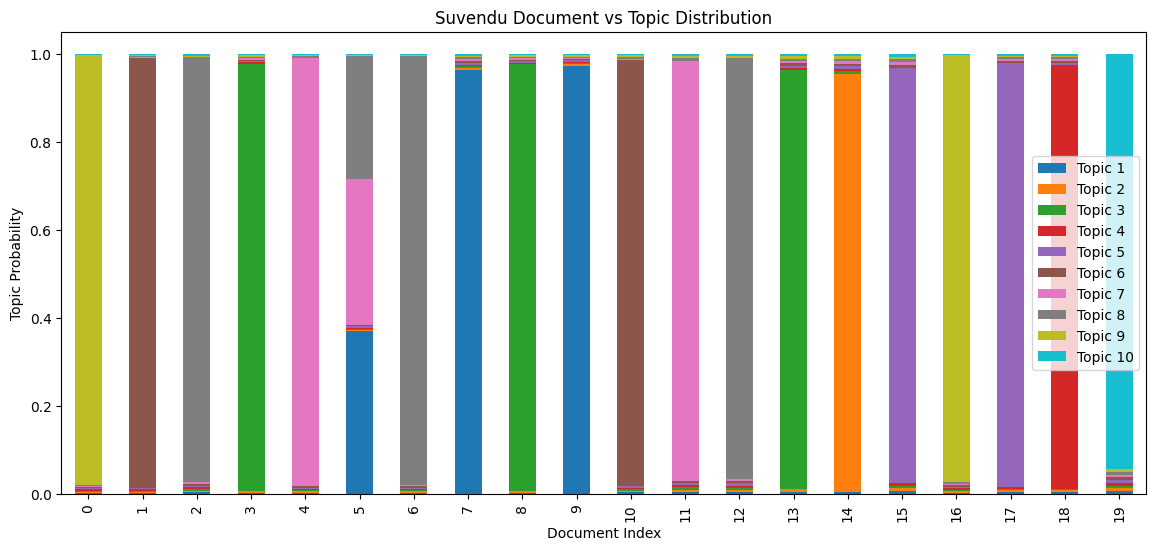

In [5]:
# ==========================================
# LOAD DATA
# ==========================================

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from collections import Counter
from itertools import combinations

# NLP
import nltk
nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Topic Modeling
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Venn Diagram
from matplotlib_venn import venn2

# Knowledge Graph
import networkx as nx

# ==========================================
# LOAD BOTH DATASETS
# ==========================================

mamata_df = pd.read_csv("mamata_banerjee_focused_dataset.csv")
suvendu_df = pd.read_csv("suvendu_adhikari_focused_dataset.csv")

# Merge quote + context text
mamata_docs = mamata_df["exact_text"].dropna().astype(str).tolist()
suvendu_docs = suvendu_df["exact_text"].dropna().astype(str).tolist()

# ==========================================
# CLEAN TEXT
# ==========================================

stop_words = set(stopwords.words("english"))

custom_stopwords = {
    "said", "will", "also", "would", "could", "one", "two",
    "west", "bengal", "election", "poll", "vote", "votes",
    "campaign", "rally", "speech", "people", "party",
    "mamata", "banerjee", "suvendu", "adhikari", "tmc", "bjp"
}

stop_words.update(custom_stopwords)

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    return " ".join(tokens)

mamata_clean = [preprocess_text(doc) for doc in mamata_docs]
suvendu_clean = [preprocess_text(doc) for doc in suvendu_docs]

# ==========================================
# LDA TOPIC MODELING FUNCTION
# ==========================================

def run_lda(documents, num_topics=10):
    vectorizer = CountVectorizer(
        max_df=0.95,
        min_df=2,
        stop_words='english'
    )

    X = vectorizer.fit_transform(documents)

    lda = LatentDirichletAllocation(
        n_components=num_topics,
        random_state=42
    )

    lda.fit(X)

    feature_names = vectorizer.get_feature_names_out()

    topics = []

    for topic_idx, topic in enumerate(lda.components_):
        top_words = [feature_names[i] for i in topic.argsort()[-10:]]
        topics.append(top_words)

        print(f"\nTopic {topic_idx + 1}:")
        print(top_words)

    return lda, X, vectorizer, topics

# ==========================================
# RUN TOPIC MODELING
# ==========================================

print("\n========== MAMATA TOPICS ==========")
mamata_lda, mamata_X, mamata_vectorizer, mamata_topics = run_lda(mamata_clean, num_topics=10)

print("\n========== SUVENDU TOPICS ==========")
suvendu_lda, suvendu_X, suvendu_vectorizer, suvendu_topics = run_lda(suvendu_clean, num_topics=10)

# ==========================================
# EXTRACT UNIQUE TOPIC WORDS
# ==========================================

mamata_topic_words = set()
for topic in mamata_topics:
    mamata_topic_words.update(topic)

suvendu_topic_words = set()
for topic in suvendu_topics:
    suvendu_topic_words.update(topic)

common_topics = mamata_topic_words.intersection(suvendu_topic_words)
mamata_unique = mamata_topic_words - suvendu_topic_words
suvendu_unique = suvendu_topic_words - mamata_topic_words

print("\nCommon Topics:")
print(common_topics)

print("\nMamata Unique Topics:")
print(mamata_unique)

print("\nSuvendu Unique Topics:")
print(suvendu_unique)

# ==========================================
# VENN DIAGRAM
# ==========================================

plt.figure(figsize=(10, 8))

venn2(
    [mamata_topic_words, suvendu_topic_words],
    set_labels=("Mamata Banerjee", "Suvendu Adhikari")
)

plt.title("Common vs Unique Topic Words")
plt.show()

# ==========================================
# TOPIC FREQUENCY BAR CHART
# ==========================================

mamata_counter = Counter()
for topic in mamata_topics:
    mamata_counter.update(topic)

suvendu_counter = Counter()
for topic in suvendu_topics:
    suvendu_counter.update(topic)

mamata_top10 = mamata_counter.most_common(10)
suvendu_top10 = suvendu_counter.most_common(10)

# Mamata Top Topics
mamata_words = [x[0] for x in mamata_top10]
mamata_counts = [x[1] for x in mamata_top10]

plt.figure(figsize=(10, 6))
plt.barh(mamata_words, mamata_counts)
plt.title("Top 10 Mamata Banerjee Topics")
plt.xlabel("Frequency")
plt.show()

# Suvendu Top Topics
suvendu_words = [x[0] for x in suvendu_top10]
suvendu_counts = [x[1] for x in suvendu_top10]

plt.figure(figsize=(10, 6))
plt.barh(suvendu_words, suvendu_counts)
plt.title("Top 10 Suvendu Adhikari Topics")
plt.xlabel("Frequency")
plt.show()

# ==========================================
# KNOWLEDGE GRAPH OF COMMON TOPICS
# ==========================================

G = nx.Graph()

# Add common topic nodes
for topic in common_topics:
    G.add_node(topic, category="Common")

# Add Mamata-only nodes
for topic in list(mamata_unique)[:15]:
    G.add_node(topic, category="Mamata")

# Add Suvendu-only nodes
for topic in list(suvendu_unique)[:15]:
    G.add_node(topic, category="Suvendu")

# Connect common topics to Mamata topics
for common_topic in common_topics:
    for topic in list(mamata_unique)[:5]:
        G.add_edge(common_topic, topic)

# Connect common topics to Suvendu topics
for common_topic in common_topics:
    for topic in list(suvendu_unique)[:5]:
        G.add_edge(common_topic, topic)

# Plot Graph
plt.figure(figsize=(16, 12))

pos = nx.spring_layout(G, k=1.2, seed=42)

common_nodes = [n for n, attr in G.nodes(data=True) if attr["category"] == "Common"]
mamata_nodes = [n for n, attr in G.nodes(data=True) if attr["category"] == "Mamata"]
suvendu_nodes = [n for n, attr in G.nodes(data=True) if attr["category"] == "Suvendu"]

nx.draw_networkx_nodes(G, pos, nodelist=common_nodes, node_size=1800)
nx.draw_networkx_nodes(G, pos, nodelist=mamata_nodes, node_size=1400)
nx.draw_networkx_nodes(G, pos, nodelist=suvendu_nodes, node_size=1400)

nx.draw_networkx_edges(G, pos, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=9)

plt.title("Knowledge Graph of Common and Unique Topics")
plt.axis("off")
plt.show()

# ==========================================
# DOCUMENT TOPIC DISTRIBUTION
# ==========================================

mamata_doc_topics = mamata_lda.transform(mamata_X)
mamata_topic_df = pd.DataFrame(
    mamata_doc_topics,
    columns=[f"Topic {i+1}" for i in range(10)]
)

mamata_topic_df["Dominant Topic"] = mamata_topic_df.idxmax(axis=1)

mamata_topic_df.drop("Dominant Topic", axis=1).plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6)
)

plt.title("Mamata Document vs Topic Distribution")
plt.xlabel("Document Index")
plt.ylabel("Topic Probability")
plt.show()

suvendu_doc_topics = suvendu_lda.transform(suvendu_X)
suvendu_topic_df = pd.DataFrame(
    suvendu_doc_topics,
    columns=[f"Topic {i+1}" for i in range(10)]
)

suvendu_topic_df["Dominant Topic"] = suvendu_topic_df.idxmax(axis=1)

suvendu_topic_df.drop("Dominant Topic", axis=1).plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6)
)

plt.title("Suvendu Document vs Topic Distribution")
plt.xlabel("Document Index")
plt.ylabel("Topic Probability")
plt.show()

In [6]:
pip install matplotlib-venn

Note: you may need to restart the kernel to use updated packages.


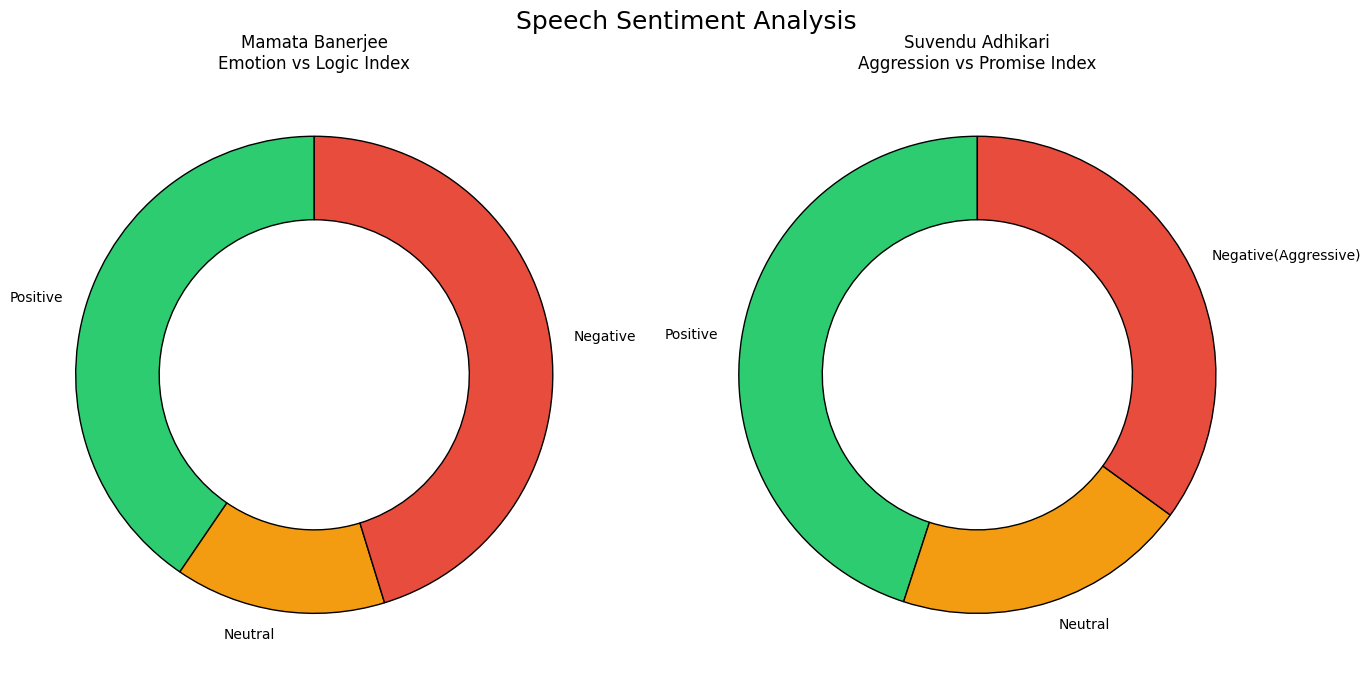


========== MAMATA SENTIMENT ==========
sentiment
Negative    19
Positive    17
Neutral      6
Name: count, dtype: int64

========== SUVENDU SENTIMENT ==========
sentiment
Positive                9
Negative(Aggressive)    7
Neutral                 4
Name: count, dtype: int64


In [7]:
# ==========================================
# SENTIMENT ANALYSIS FOR MAMATA VS SUVENDU
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob

# ==========================================
# LOAD DATA
# ==========================================

mamata_df = pd.read_csv("mamata_banerjee_focused_dataset.csv")
suvendu_df = pd.read_csv("suvendu_adhikari_focused_dataset.csv")

mamata_docs = mamata_df["exact_text"].dropna().astype(str).tolist()
suvendu_docs = suvendu_df["exact_text"].dropna().astype(str).tolist()

# ==========================================
# CUSTOM SENTIMENT FUNCTION
# ==========================================

def classify_mamata_sentiment(text):
    text = text.lower()

    positive_keywords = [
        "development", "women", "welfare", "support", "peace",
        "help", "growth", "benefit", "scheme", "education",
        "health", "unity", "employment", "rights", "progress"
    ]

    negative_keywords = [
        "violence", "attack", "corruption", "protest", "anger",
        "fear", "criticised", "slammed", "accused", "threat",
        "controversy", "riot", "opposition", "aggressive"
    ]

    positive_score = sum([1 for word in positive_keywords if word in text])
    negative_score = sum([1 for word in negative_keywords if word in text])

    polarity = TextBlob(text).sentiment.polarity

    if positive_score > negative_score or polarity > 0.15:
        return "Positive"
    elif negative_score > positive_score or polarity < -0.15:
        return "Negative"
    else:
        return "Neutral"

def classify_suvendu_sentiment(text):
    text = text.lower()

    promise_keywords = [
        "development", "jobs", "benefit", "promise", "growth",
        "improvement", "support", "future", "employment",
        "infrastructure", "better", "reform"
    ]

    aggressive_keywords = [
        "corruption", "infiltration", "cow slaughter", "violence",
        "minority appeasement", "attack", "slammed", "criticised",
        "illegal", "threat", "warning", "sandeshkhali",
        "law and order", "ucc", "protest", "riot"
    ]

    promise_score = sum([1 for word in promise_keywords if word in text])
    aggressive_score = sum([1 for word in aggressive_keywords if word in text])

    polarity = TextBlob(text).sentiment.polarity

    if aggressive_score > promise_score or polarity < -0.10:
        return "Negative(Aggressive)"
    elif promise_score > aggressive_score or polarity > 0.10:
        return "Positive"
    else:
        return "Neutral"

# ==========================================
# APPLY SENTIMENT
# ==========================================

mamata_df["sentiment"] = mamata_df["exact_text"].apply(classify_mamata_sentiment)
suvendu_df["sentiment"] = suvendu_df["exact_text"].apply(classify_suvendu_sentiment)

# ==========================================
# COUNT SENTIMENTS
# ==========================================

mamata_counts = mamata_df["sentiment"].value_counts()
suvendu_counts = suvendu_df["sentiment"].value_counts()

mamata_positive = mamata_counts.get("Positive", 0)
mamata_neutral = mamata_counts.get("Neutral", 0)
mamata_negative = mamata_counts.get("Negative", 0)

suvendu_positive = suvendu_counts.get("Positive", 0)
suvendu_neutral = suvendu_counts.get("Neutral", 0)
suvendu_negative = suvendu_counts.get("Negative(Aggressive)", 0)

# ==========================================
# CREATE DONUT CHARTS
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Common colors
positive_color = "#2ecc71"   # Green
neutral_color = "#f39c12"    # Yellow-Orange
negative_color = "#e74c3c"   # Red

# Mamata Chart
mamata_sizes = [mamata_positive, mamata_neutral, mamata_negative]
mamata_labels = ["Positive", "Neutral", "Negative"]
mamata_colors = [positive_color, neutral_color, negative_color]

axes[0].pie(
    mamata_sizes,
    labels=mamata_labels,
    colors=mamata_colors,
    startangle=90,
    wedgeprops=dict(width=0.35, edgecolor='black')
)

axes[0].set_title("Mamata Banerjee\nEmotion vs Logic Index")

# Suvendu Chart
suvendu_sizes = [suvendu_positive, suvendu_neutral, suvendu_negative]
suvendu_labels = ["Positive", "Neutral", "Negative(Aggressive)"]
suvendu_colors = [positive_color, neutral_color, negative_color]

axes[1].pie(
    suvendu_sizes,
    labels=suvendu_labels,
    colors=suvendu_colors,
    startangle=90,
    wedgeprops=dict(width=0.35, edgecolor='black')
)

axes[1].set_title("Suvendu Adhikari\nAggression vs Promise Index")

plt.suptitle("Speech Sentiment Analysis", fontsize=18)
plt.tight_layout()
plt.show()

# ==========================================
# PRINT SUMMARY
# ==========================================

print("\n========== MAMATA SENTIMENT ==========")
print(mamata_counts)

print("\n========== SUVENDU SENTIMENT ==========")
print(suvendu_counts)

# ==========================================
# OPTIONAL: SAVE RESULTS
# ==========================================

mamata_df.to_csv("mamata_sentiment_analysis.csv", index=False)
suvendu_df.to_csv("suvendu_sentiment_analysis.csv", index=False)

Common Topics: ['candidate', 'elections', 'janata', 'nandigram', 'trinamool']

Mamata Unique Topics: ['accused', 'aiadmk', 'assam', 'bangla', 'birodhi', 'biswa', 'contest', 'earlier', 'himanta', 'nadu', 'number', 'protect', 'sarma', 'seats', 'tamil']

Suvendu Unique Topics: ['civil', 'code', 'constituency', 'development', 'industries', 'land', 'manifesto', 'movement', 'place', 'power', 'still', 'support', 'uniform', 'union', 'years']


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/koustavsarkar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/koustavsarkar/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


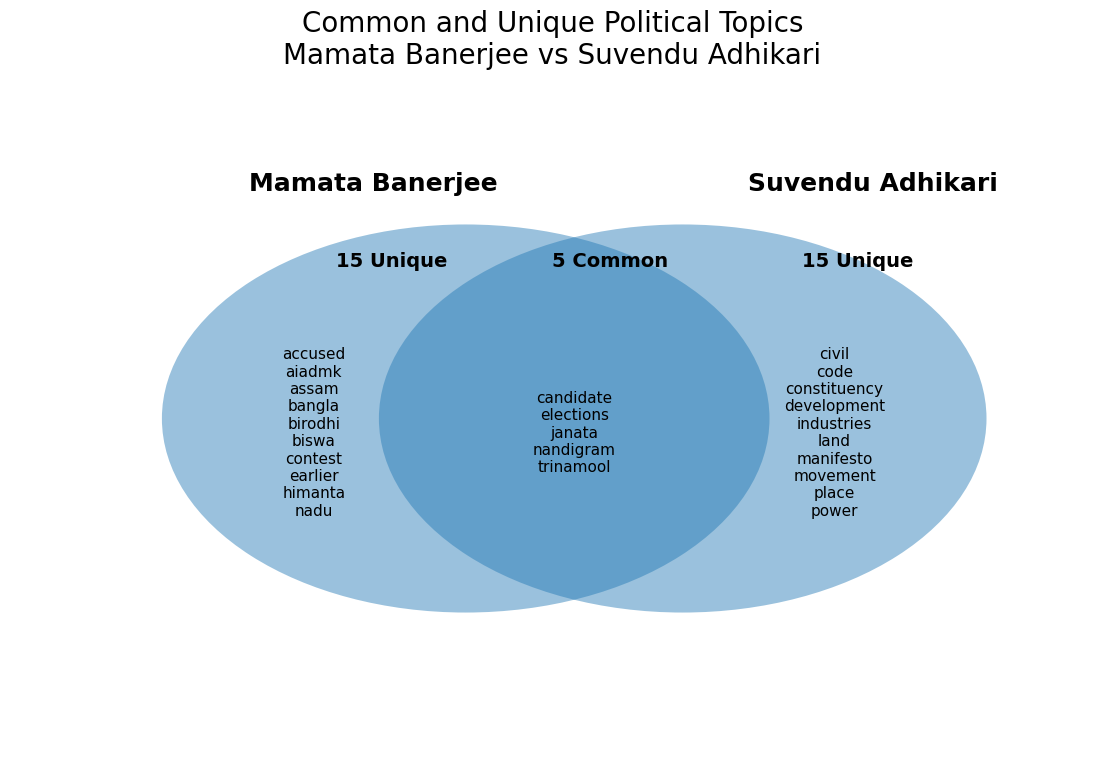

In [8]:

import pandas as pd
import re
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from collections import Counter
import nltk

nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# ==========================================
# LOAD DATA
# ==========================================

mamata_df = pd.read_csv("mamata_banerjee_focused_dataset.csv")
suvendu_df = pd.read_csv("suvendu_adhikari_focused_dataset.csv")

mamata_text = " ".join(mamata_df["exact_text"].dropna().astype(str))
suvendu_text = " ".join(suvendu_df["exact_text"].dropna().astype(str))

# ==========================================
# CLEAN TEXT
# ==========================================

stop_words = set(stopwords.words("english"))

custom_stopwords = {
    "said", "says", "also", "would", "could", "will",
    "west", "bengal", "election", "poll", "vote", "votes",
    "campaign", "rally", "speech", "people", "party",
    "mamata", "banerjee", "suvendu", "adhikari", "tmc", "bjp",
    "minister", "prime", "state", "government", "today",
    "india", "indian", "leader", "leaders", "public",
    "meeting", "roadshow", "assembly", "political",
    "district", "modi", "amit", "shah", "chief",
    "home", "congress", "april", "friday", "saturday"
}

stop_words.update(custom_stopwords)

def clean_and_tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    tokens = word_tokenize(text)

    tokens = [
        word for word in tokens
        if word not in stop_words
        and len(word) > 3
    ]

    return tokens

mamata_tokens = clean_and_tokenize(mamata_text)
suvendu_tokens = clean_and_tokenize(suvendu_text)

# ==========================================
# GET TOP 20 MOST COMMON POLITICAL WORDS
# ==========================================

mamata_counter = Counter(mamata_tokens)
suvendu_counter = Counter(suvendu_tokens)

mamata_top = [word for word, count in mamata_counter.most_common(20)]
suvendu_top = [word for word, count in suvendu_counter.most_common(20)]

# ==========================================
# FIND COMMON + UNIQUE
# ==========================================

mamata_set = set(mamata_top)
suvendu_set = set(suvendu_top)

common_topics = sorted(list(mamata_set.intersection(suvendu_set)))
mamata_unique = sorted(list(mamata_set - suvendu_set))
suvendu_unique = sorted(list(suvendu_set - mamata_set))

print("Common Topics:", common_topics)
print("\nMamata Unique Topics:", mamata_unique)
print("\nSuvendu Unique Topics:", suvendu_unique)

# ==========================================
# LIMIT TEXT FOR DISPLAY
# ==========================================

mamata_text_display = "\n".join(mamata_unique[:10])
common_text_display = "\n".join(common_topics[:10])
suvendu_text_display = "\n".join(suvendu_unique[:10])

# ==========================================
# CREATE VENN DIAGRAM
# ==========================================

fig, ax = plt.subplots(figsize=(14, 9))

left_circle = Circle((0.42, 0.5), 0.28, alpha=0.45)
right_circle = Circle((0.62, 0.5), 0.28, alpha=0.45)

ax.add_patch(left_circle)
ax.add_patch(right_circle)

# Titles
plt.text(0.22, 0.83, "Mamata Banerjee", fontsize=18, fontweight='bold')
plt.text(0.68, 0.83, "Suvendu Adhikari", fontsize=18, fontweight='bold')

# Counts
plt.text(0.30, 0.72, f"{len(mamata_unique)} Unique", fontsize=14, fontweight='bold')
plt.text(0.50, 0.72, f"{len(common_topics)} Common", fontsize=14, fontweight='bold')
plt.text(0.73, 0.72, f"{len(suvendu_unique)} Unique", fontsize=14, fontweight='bold')

# Topic Text
plt.text(0.28, 0.48, mamata_text_display, fontsize=11, ha='center', va='center')
plt.text(0.52, 0.48, common_text_display, fontsize=11, ha='center', va='center')
plt.text(0.76, 0.48, suvendu_text_display, fontsize=11, ha='center', va='center')

plt.title(
    "Common and Unique Political Topics\nMamata Banerjee vs Suvendu Adhikari",
    fontsize=20
)

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.axis("off")
plt.show()

In [9]:
# Count total unique topic words from both files

mamata_unique_count = len(mamata_unique)
suvendu_unique_count = len(suvendu_unique)
common_count = len(common_topics)

print("Mamata Unique Topic Count:", mamata_unique_count)
print("Suvendu Unique Topic Count:", suvendu_unique_count)
print("Common Topic Count:", common_count)

print("\nTotal Distinct Topics Across Both Files:")
total_distinct_topics = len(mamata_set.union(suvendu_set))
print(total_distinct_topics)

Mamata Unique Topic Count: 15
Suvendu Unique Topic Count: 15
Common Topic Count: 5

Total Distinct Topics Across Both Files:
35



========== MAMATA TOPICS ==========

Topic 1: Modi vs Mamata Political Rivalry
Keywords: ['acquisition', 'bridge', 'group', 'roads', 'land', 'trinamool', 'resistance', 'political', 'movement', 'nandigram']

Topic 2: Voters, Public Meetings and State Issues
Keywords: ['state', 'muraleedharan', 'total', 'chief', 'number', 'polling', 'alleged', 'union', 'kabir', 'minister']

Topic 3: Nandigram Movement and Land Politics
Keywords: ['minister', 'kabir', 'trinamool', 'women', 'congress', 'alleged', 'union', 'quota', 'law', 'amendment']

Topic 4: Regional Alliances and Leadership
Keywords: ['deeper', 'sense', 'cast', 'arrive', 'agitation', 'remains', 'land', 'completed', 'development', 'place']

Topic 5: Land Acquisition and Bhabanipur Politics
Keywords: ['news', 'trinamool', 'congress', 'politics', 'nandigram', 'minister', 'shah', 'amit', 'home', 'bhabanipur']

Topic 6: Assembly Elections and Government Criticism
Keywords: ['sharma', 'shankar', 'ghosh', 'drug', 'chief', 'minister', 'constit

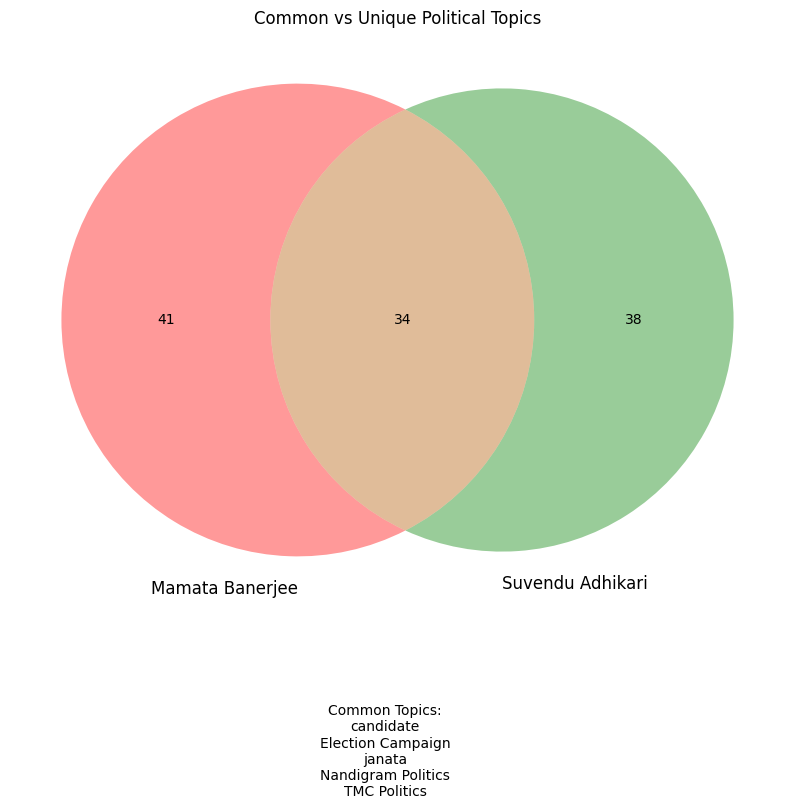

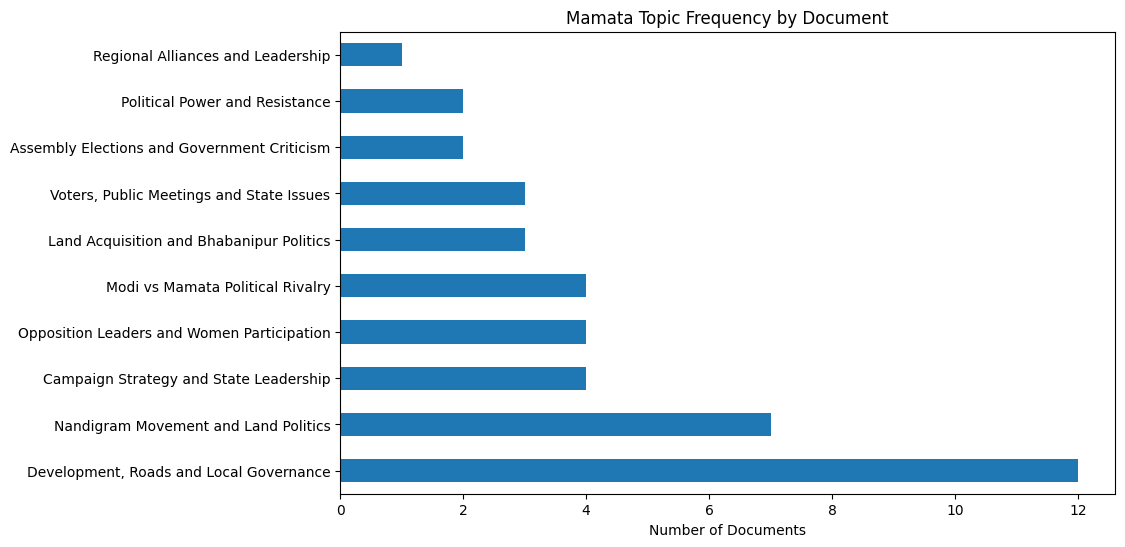

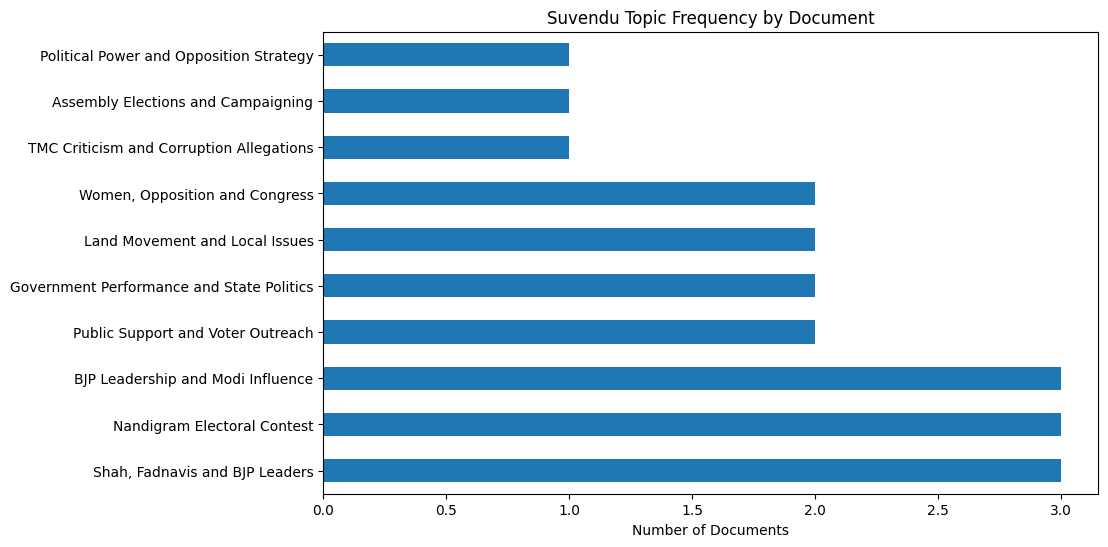

In [10]:
# ==========================================
# EXPLICIT TOPIC NAMING FOR EACH LEADER
# ==========================================

# Example topic names based on top keywords
# You can increase or decrease the number of topics

mamata_topic_names = {
    0: "Modi vs Mamata Political Rivalry",
    1: "Voters, Public Meetings and State Issues",
    2: "Nandigram Movement and Land Politics",
    3: "Regional Alliances and Leadership",
    4: "Land Acquisition and Bhabanipur Politics",
    5: "Assembly Elections and Government Criticism",
    6: "Opposition Leaders and Women Participation",
    7: "Development, Roads and Local Governance",
    8: "Political Power and Resistance",
    9: "Campaign Strategy and State Leadership"
}

suvendu_topic_names = {
    0: "BJP Leadership and Modi Influence",
    1: "TMC Criticism and Corruption Allegations",
    2: "Nandigram Electoral Contest",
    3: "Assembly Elections and Campaigning",
    4: "Women, Opposition and Congress",
    5: "Government Performance and State Politics",
    6: "Land Movement and Local Issues",
    7: "Shah, Fadnavis and BJP Leaders",
    8: "Public Support and Voter Outreach",
    9: "Political Power and Opposition Strategy"
}

# ==========================================
# PRINT TOPICS WITH EXPLICIT NAMES
# ==========================================

print("\n========== MAMATA TOPICS ==========")
for idx, topic_words in enumerate(mamata_topics):
    print(f"\nTopic {idx+1}: {mamata_topic_names.get(idx, 'Other Topic')}")
    print("Keywords:", topic_words)

print("\n========== SUVENDU TOPICS ==========")
for idx, topic_words in enumerate(suvendu_topics):
    print(f"\nTopic {idx+1}: {suvendu_topic_names.get(idx, 'Other Topic')}")
    print("Keywords:", topic_words)

# ==========================================
# ASSIGN DOMINANT TOPIC NAME TO EACH DOCUMENT
# ==========================================

mamata_doc_topics = mamata_lda.transform(mamata_X)
mamata_dominant_topic = mamata_doc_topics.argmax(axis=1)

mamata_topic_assignment = pd.DataFrame({
    "Document": mamata_docs,
    "Dominant Topic No": mamata_dominant_topic + 1,
    "Dominant Topic Name": [
        mamata_topic_names.get(i, "Other Topic")
        for i in mamata_dominant_topic
    ]
})

print("\n========== MAMATA DOCUMENT TOPIC ASSIGNMENT ==========")
print(mamata_topic_assignment.head(20))

suvendu_doc_topics = suvendu_lda.transform(suvendu_X)
suvendu_dominant_topic = suvendu_doc_topics.argmax(axis=1)

suvendu_topic_assignment = pd.DataFrame({
    "Document": suvendu_docs,
    "Dominant Topic No": suvendu_dominant_topic + 1,
    "Dominant Topic Name": [
        suvendu_topic_names.get(i, "Other Topic")
        for i in suvendu_dominant_topic
    ]
})

print("\n========== SUVENDU DOCUMENT TOPIC ASSIGNMENT ==========")
print(suvendu_topic_assignment.head(20))

# ==========================================
# SAVE TOPIC ASSIGNMENTS TO CSV
# ==========================================

mamata_topic_assignment.to_csv(
    "mamata_document_topic_assignment.csv",
    index=False
)

suvendu_topic_assignment.to_csv(
    "suvendu_document_topic_assignment.csv",
    index=False
)

# ==========================================
# COMMON TOPIC LABELS FOR VENN DIAGRAM
# ==========================================

common_topic_labels = {
    "nandigram": "Nandigram Politics",
    "minister": "Leadership and Ministers",
    "chief": "Chief Minister Debate",
    "state": "State Politics",
    "assembly": "Assembly Elections",
    "trinamool": "TMC Politics",
    "elections": "Election Campaign",
    "power": "Political Power"
}

print("\n========== COMMON TOPIC LABELS ==========")
for topic in common_topics:
    if topic in common_topic_labels:
        print(topic, "->", common_topic_labels[topic])

# ==========================================
# BETTER VENN DIAGRAM WITH COMMON TOPIC LABELS
# ==========================================

plt.figure(figsize=(10, 8))

venn = venn2(
    [mamata_topic_words, suvendu_topic_words],
    set_labels=("Mamata Banerjee", "Suvendu Adhikari")
)

plt.title("Common vs Unique Political Topics")

# Show explicit common topics below plot
common_text = "\n".join([
    common_topic_labels.get(topic, topic)
    for topic in sorted(common_topics)
])

plt.figtext(
    0.5,
    -0.1,
    f"Common Topics:\n{common_text}",
    ha="center",
    fontsize=10
)

plt.show()

# ==========================================
# OPTIONAL: SHOW TOPIC NAME FREQUENCY
# ==========================================

mamata_topic_freq = pd.Series(
    [mamata_topic_names[i] for i in mamata_dominant_topic]
).value_counts()

plt.figure(figsize=(10, 6))
mamata_topic_freq.plot(kind="barh")
plt.title("Mamata Topic Frequency by Document")
plt.xlabel("Number of Documents")
plt.show()

suvendu_topic_freq = pd.Series(
    [suvendu_topic_names[i] for i in suvendu_dominant_topic]
).value_counts()

plt.figure(figsize=(10, 6))
suvendu_topic_freq.plot(kind="barh")
plt.title("Suvendu Topic Frequency by Document")
plt.xlabel("Number of Documents")
plt.show()


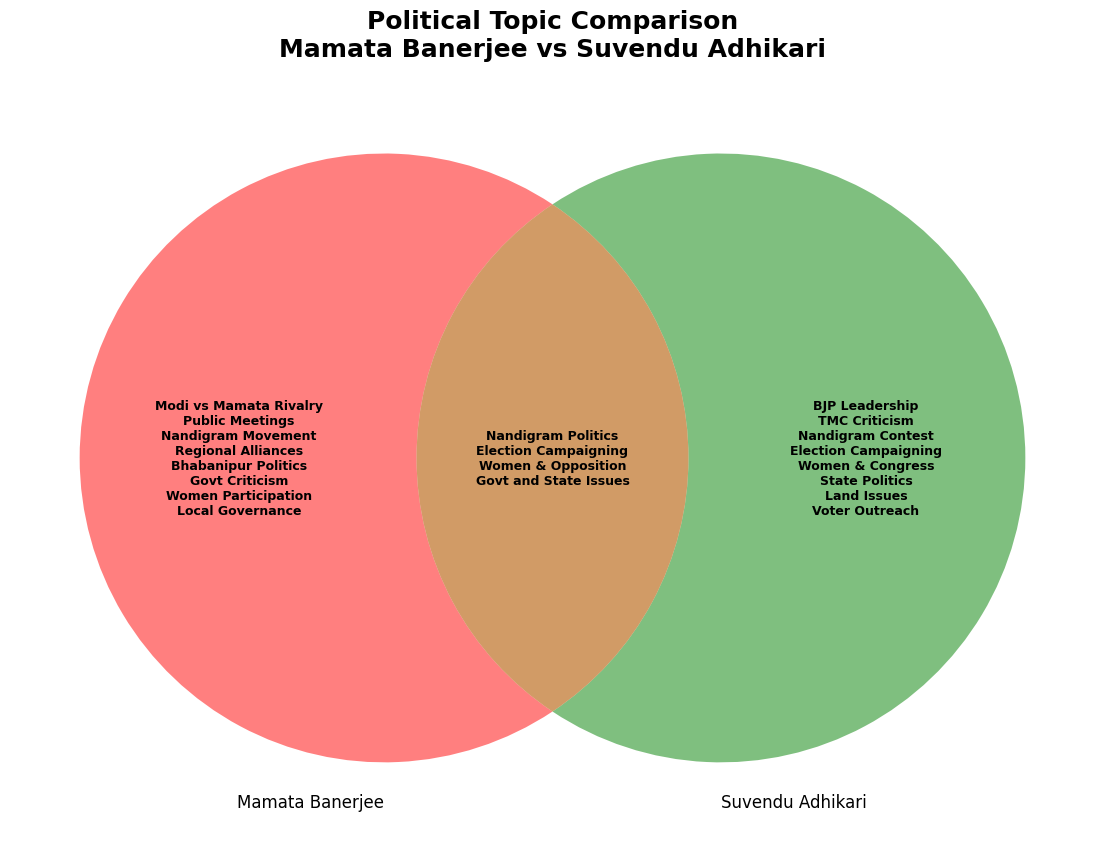

In [13]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

# ==========================================
# SHORT TOPIC LABELS
# ==========================================

mamata_topics_text = "\n".join([
    "Modi vs Mamata Rivalry",
    "Public Meetings",
    "Nandigram Movement",
    "Regional Alliances",
    "Bhabanipur Politics",
    "Govt Criticism",
    "Women Participation",
    "Local Governance"
])

common_topics_text = "\n".join([
    "Nandigram Politics",
    "Election Campaigning",
    "Women & Opposition",
    "Govt and State Issues"
])

suvendu_topics_text = "\n".join([
    "BJP Leadership",
    "TMC Criticism",
    "Nandigram Contest",
    "Election Campaigning",
    "Women & Congress",
    "State Politics",
    "Land Issues",
    "Voter Outreach"
])

# ==========================================
# CREATE VENN DIAGRAM
# ==========================================

fig, ax = plt.subplots(figsize=(14, 10))

venn = venn2(
    subsets=(8, 8, 4),
    set_labels=("Mamata Banerjee", "Suvendu Adhikari")
)

# Change colors
venn.get_patch_by_id('10').set_alpha(0.5)
venn.get_patch_by_id('01').set_alpha(0.5)
venn.get_patch_by_id('11').set_alpha(0.6)

# Remove default numbers
for subset in ['10', '01', '11']:
    label = venn.get_label_by_id(subset)
    if label:
        label.set_text('')

# Left Circle Text
ax.text(
    -0.45, 0,
    mamata_topics_text,
    fontsize=9,
    ha='center',
    va='center',
    fontweight='bold'
)

# Center Overlap Text
ax.text(
    0, 0,
    common_topics_text,
    fontsize=9,
    ha='center',
    va='center',
    fontweight='bold'
)

# Right Circle Text
ax.text(
    0.45, 0,
    suvendu_topics_text,
    fontsize=9,
    ha='center',
    va='center',
    fontweight='bold'
)

plt.title(
    "Political Topic Comparison\nMamata Banerjee vs Suvendu Adhikari",
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.show()